# Aplicación de clustering espacialmente restringido 

Se muestra una aplicación de los métodos de clustering espacialmente restringido a los casos de COVID en los departamentos/partidos de Argentina.

## Instalación 

In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Raíz del proyecto añadida al path: {project_root}")
from constantes import *
from datos.scripts_preproceso.lectura_datos_covid import *
import SDEC.regionalizacion as reg
import matplotlib.pyplot as plt
import SDEC.deep_cluster as dc
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


%matplotlib inline
%load_ext autoreload
%autoreload 2



Raíz del proyecto añadida al path: d:\Archivos\Codigos\clustering espacial


## Lectura de datos

In [2]:
covid,geo, centroides, codiprov,covid_acum,personas = df_covid()

c:\Users\Pablo\miniconda3\envs\sdec\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver ESRI Shapefile does not support open option INDEX
  return ogr_read(


El mes desde el cuál todos los dptos tienen al menos 1 contagiado es: 2021-01


In [3]:
cov = reg.Datos(covid, ['clasificac','fallecido'], 'personas')
df = cov.convertir_a_df(cov.panel_df,['clasificac','fallecido'])
# calculamos la proporcion de cada variable en cada periodo del total de la población
prop = df.iloc[:,:-1].values/df.personas.values.reshape(-1,1)
prop.shape

(525, 34)

In [4]:
from sklearn.preprocessing import StandardScaler
st = StandardScaler()
prop_st = st.fit_transform(prop)


In [5]:
geo_prop = gpd.GeoDataFrame(prop_st,columns =  np.array(range(34), str), geometry = geo.reset_index().geometry)
#geo_prop.to_file("SDEC/datos/datos/geo_prop.shp")

In [6]:
km = KMeans(8)
km.fit(prop_st)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [7]:
km.inertia_

11072.996685875452

In [8]:
import SDEC.sumacuadrados as suc
suc.SSD(prop_st,km.labels_)

[[1. 1.]
 [1. 1.]] 1014616.1127182182 3.1887651055205828e-25 0.03141419063700357


{'TSS': np.float64(19212.678593966702),
 'WSS': np.float64(1408.1759024376292),
 'BSS': np.float64(7947.2713744656685),
 'RBTSS': np.float64(0.41364723485049737)}

In [9]:
suc.SSD(prop,np.random.randint(0,8,525))

{'TSS': np.float64(0.39697426980487677),
 'WSS': np.float64(0.048449365817312906),
 'BSS': np.float64(0.009379343266373519),
 'RBTSS': np.float64(0.023627081097683512)}

## Resultados obtenidos

Se muestran los resultados obtenidos en el paper

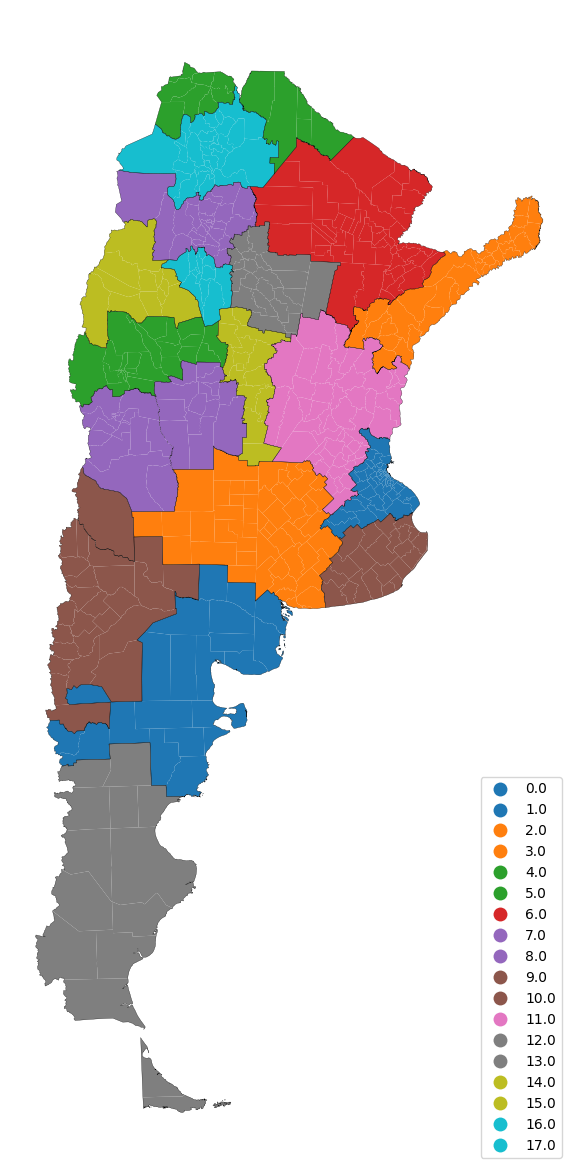

In [11]:
rdos = pd.read_csv(os.path.join(DIR_RESULTADOS, "covid/covid_sdec.csv"))
clusters = rdos.iloc[:,-1]

geo_prop
geos = []

for i in np.unique(clusters):
    g = geo_prop.geometry[clusters == i].union_all()
    geos.append(g)

geos = gpd.GeoSeries(geos)
base = geos.boundary.plot(figsize = (10,15), color = 'black', edgecolor = 'black', linewidth = 0.2)
graf = geo_prop.plot(clusters, figsize = (10,8), categorical = True,legend = True,legend_kwds = {'loc':'lower right'}, ax = base)

graf.set_axis_off()

## Aplicación de spatial deep embeding clustering


In [12]:
sc = dc.sdec(18, [17,17])
cov.matriz_W(6)
W = cov.W_knn

d:\Archivos\Codigos\clustering espacial\SDEC\regionalizacion.py:102: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  self.W_queen = Queen.from_dataframe(df)
c:\Users\Pablo\miniconda3\envs\sdec\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)
d:\Archivos\Codigos\clustering espacial\SDEC\regionalizacion.py:103: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  self.W_rook = Rook.from_dataframe(df)
c:\Users\Pablo\miniconda3\envs\sdec\Lib\site-packages\libpysal\weights\contiguity.py:61: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


In [13]:
np.random.seed(42)
X1 = prop_st[:,:17]
X2 = prop_st[:,17:]
sc.gen_modelo()
sc.train_autoencoder([X1,X2],prop)
sc.ajustar_modelo([X1,X2], W.sparse)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


<Axes: >

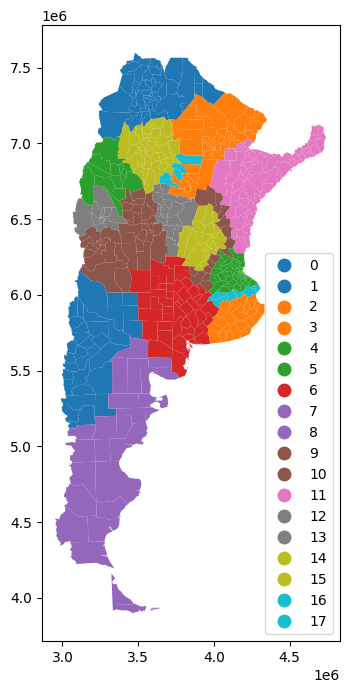

In [14]:
geo_prop.plot(sc.y_pred, figsize = (10,8), categorical = True,legend = True,legend_kwds = {'loc':'lower right'})

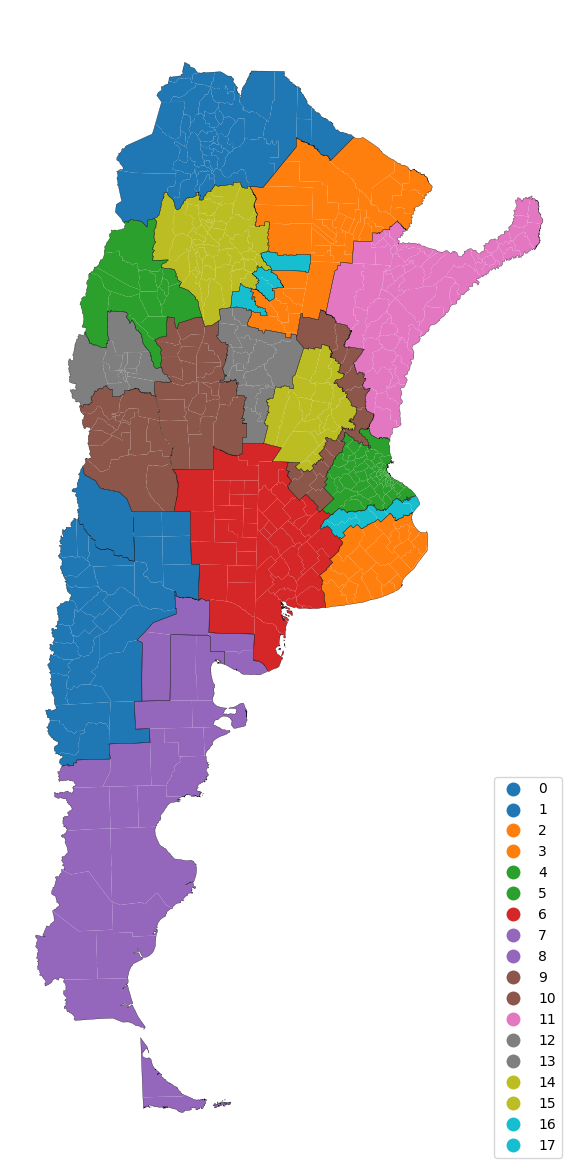

In [15]:
geo_prop
geos = []

for i in np.unique(sc.y_pred):
    g = geo_prop.geometry[sc.y_pred == i].union_all()
    geos.append(g)

geos = gpd.GeoSeries(geos)
base = geos.boundary.plot(figsize = (10,15), color = 'black', edgecolor = 'black', linewidth = 0.2)
graf = geo_prop.plot(sc.y_pred, figsize = (10,8), categorical = True,legend = True,legend_kwds = {'loc':'lower right'}, ax = base)

graf.set_axis_off()

Evaluación de los clusters formados con SDEC

In [16]:
loss = sc.autoencoder.evaluate([X1, X2], prop_st, verbose=1)
print("Pérdida de reconstrucción (cosine_similarity):", loss)
# Obtener embeddings del encoder
embeddings = sc.encoder.predict([X1, X2])

labels = sc.y_pred  # O el atributo correspondiente
print("Silhouette:", silhouette_score(embeddings, labels))
print("Calinski-Harabasz:", calinski_harabasz_score(embeddings, labels))
print("Davies-Bouldin:", davies_bouldin_score(embeddings, labels))

print(suc.SSD(embeddings, labels))
print(suc.SSD(prop_st, labels))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: -0.1184 
Pérdida de reconstrucción (cosine_similarity): -0.11839349567890167
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Silhouette: 0.6118074655532837
Calinski-Harabasz: 1528.615276420964
Davies-Bouldin: 1.2949429146521785
{'TSS': np.float32(80743.42), 'WSS': np.float32(64.24613), 'BSS': np.float32(79586.99), 'RBTSS': np.float32(0.9856777)}
{'TSS': np.float64(19212.678593966702), 'WSS': np.float64(773.6267664753288), 'BSS': np.float64(5287.396797410784), 'RBTSS': np.float64(0.2752035210265355)}


In [17]:
from sklearn.metrics import *

def metricas_intrinsecas(datos, grupos):
    sil = round(silhouette_score(datos,grupos),5)
    cal = round(calinski_harabasz_score(datos,grupos),5)
    dav = round(davies_bouldin_score(datos, grupos),5)
    rdo = pd.DataFrame([sil,cal,dav], index = ['Siluetas', 'Kalinski','Davies'])
    return rdo

In [18]:
r_sc = metricas_intrinsecas(prop, sc.y_pred)

r_sc.columns = ['SDEC']
r_sc

,SDEC
Siluetas,-0.17555
Kalinski,12.16657
Davies,4.24245


Calculando las metricas sobre los autoencoders ahí si arroja buenos resultados SDEC y los otros siguen siendo malos

In [19]:
encoders = sc.encoder.predict([X1,X2])
r_enco_sc = metricas_intrinsecas(encoders, sc.y_pred)
r_enco_sc.columns = ['SDEC']
r_enco_sc



17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,SDEC
Siluetas,0.61181
Kalinski,1528.61528
Davies,1.29494


In [20]:
suc.SSD(prop_st, sc.y_pred)

{'TSS': np.float64(19212.678593966702),
 'WSS': np.float64(773.6267664753288),
 'BSS': np.float64(5287.396797410784),
 'RBTSS': np.float64(0.2752035210265355)}

In [21]:
#pd.DataFrame(np.c_[prop_st, sc.y_pred]).to_csv("resultados/covid_sdec.csv")

In [22]:
pred = sc.autoencoder.predict([X1,X2])
mean_squared_error(prop_st, pred)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


0.9942742358421726

## Interpretación con mapas

In [23]:
def graficar_mapa_clusters(gdf, clusters, geos, percentiles=(5, 95), años = [2015, 2018, 2023], promedio = False):
    """
    Graficar los clusters en un mapa utilizando GeoDataFrame y resultados de clustering.
    
    Args:
        gdf (GeoDataFrame): GeoDataFrame con los datos a graficar.
        sc (object): Objeto con los resultados del clustering.
        geos (GeoSeries): GeoSeries con las geometrías de los clusters.
    """

    valores = gdf.iloc[:,:-1].values.flatten()
    vmin = np.percentile(valores, percentiles[0])
    vmax = np.percentile(valores, percentiles[1])
    escalas_colores = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'Greys']
    escalas_colores = (escalas_colores * ((len(np.unique(sc.y_pred)) // len(escalas_colores)) + 1))[:len(np.unique(sc.y_pred))]

    fig, ax = plt.subplots(1, 3, figsize=(20, 15))
    for idx, año in enumerate(años):
        base = geos.boundary.plot(color='black', edgecolor='black', linewidth=0.8, ax=ax[idx])
        for i in np.unique(clusters):
            gdf_ = gdf[clusters == i].copy()
            gdf_.loc[:,'prom'] = gdf_[año].mean()
            col = 'prom' if promedio else año
            gdf_.plot(col, cmap=escalas_colores[i], ax=base, vmin=vmin, vmax=vmax)
            base.set_title(año)
            base.set_axis_off()
    

In [24]:
geo_prop
geos = []

for i in np.unique(sc.y_pred):
    g = geo_prop.geometry[sc.y_pred == i].union_all()
    geos.append(g)

geos = gpd.GeoSeries(geos)

In [25]:
geo_prop.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', 'geometry'],
      dtype='str')

In [26]:
import pandas as pd

# Crear un rango de fechas desde marzo 2020 hasta julio 2021
date_range = pd.date_range(start='2020-03-01', end='2021-07-01', freq='MS')
# Formatear como 'Month-YYYY' con meses en inglés
index_months = [d.strftime('%B-%Y') for d in date_range]
print(index_months)

['March-2020', 'April-2020', 'May-2020', 'June-2020', 'July-2020', 'August-2020', 'September-2020', 'October-2020', 'November-2020', 'December-2020', 'January-2021', 'February-2021', 'March-2021', 'April-2021', 'May-2021', 'June-2021', 'July-2021']


In [27]:
n_geo = geo_prop.loc[:,:'16']
n_geo.columns = index_months
n_geo = gpd.GeoDataFrame(n_geo, geometry=geo_prop.geometry)
n_geo

,March-2020,April-2020,May-2020,June-2020,July-2020,August-2020,September-2020,October-2020,November-2020,December-2020,January-2021,February-2021,March-2021,April-2021,May-2021,June-2021,July-2021,geometry
0,0.525727,1.131479,17.941613,2.939973,1.182836,0.916872,-0.129864,-0.561046,-0.603093,-0.341544,-0.183079,-0.118417,-0.116110,0.111398,-0.472662,-1.078586,-1.023274,"POLYGON ((4200350.769 6147470.664, 4201101.267..."
1,1.112432,0.013858,0.833253,0.444914,0.223000,0.113989,-0.370758,-0.475127,-0.495764,-0.059310,0.170978,0.194884,0.189440,0.172787,-0.569401,-1.044722,-0.922949,"POLYGON ((4198043.775 6148577.659, 4198111.775..."
2,1.258273,0.169296,1.816551,3.189853,1.439562,1.164108,-0.119313,-0.434174,-0.538868,-0.343796,-0.132386,-0.088092,0.149286,0.448826,-0.255701,-0.931536,-0.978494,"POLYGON ((4198450.276 6145157.669, 4198456.277..."
3,-0.082813,0.262873,4.182255,8.580371,2.486270,1.668335,-0.064495,-0.435356,-0.531509,-0.315170,-0.234155,-0.147688,0.099760,0.489578,-0.194575,-0.896327,-1.014130,"POLYGON ((4201672.77 6142869.179, 4201695.77 6..."
4,0.326956,0.229925,0.706467,1.712132,0.670755,0.630046,-0.167299,-0.455979,-0.545880,-0.297451,-0.121690,0.029780,0.130117,0.307600,-0.368934,-1.001508,-0.906357,"POLYGON ((4196342.782 6145516.166, 4196373.783..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,-0.052570,-0.090964,-0.209211,-0.335597,-0.271708,-0.026741,1.037454,2.501907,1.295136,-0.129385,-0.545533,-0.374756,0.489706,0.528015,-0.170812,0.708458,1.054173,"POLYGON ((3528344.175 7068079.973, 3528726.423..."
521,-0.236998,-0.241914,-0.001967,-0.381938,-0.312088,-0.497583,0.029706,-0.089884,-0.014681,-0.309833,-0.669506,-0.746777,-0.293726,0.534877,-0.115082,0.152969,0.134811,"POLYGON ((3545611.595 7114982.766, 3545704.095..."
522,0.510028,-0.046259,-0.131857,-0.281830,-0.307418,-0.034288,1.361356,2.483968,1.143238,0.215893,0.093525,0.274151,1.585074,0.983671,-0.071764,0.854512,1.633956,"POLYGON ((3574142.728 7037932.61, 3573938.229 ..."
523,0.563717,0.334806,-0.213757,-0.355112,1.230827,4.658920,4.682895,7.539773,3.607164,1.196560,0.828308,0.470526,0.363211,0.328167,-0.467019,-0.886325,0.026290,"POLYGON ((3331409.067 3951568.417, 3330689.068..."


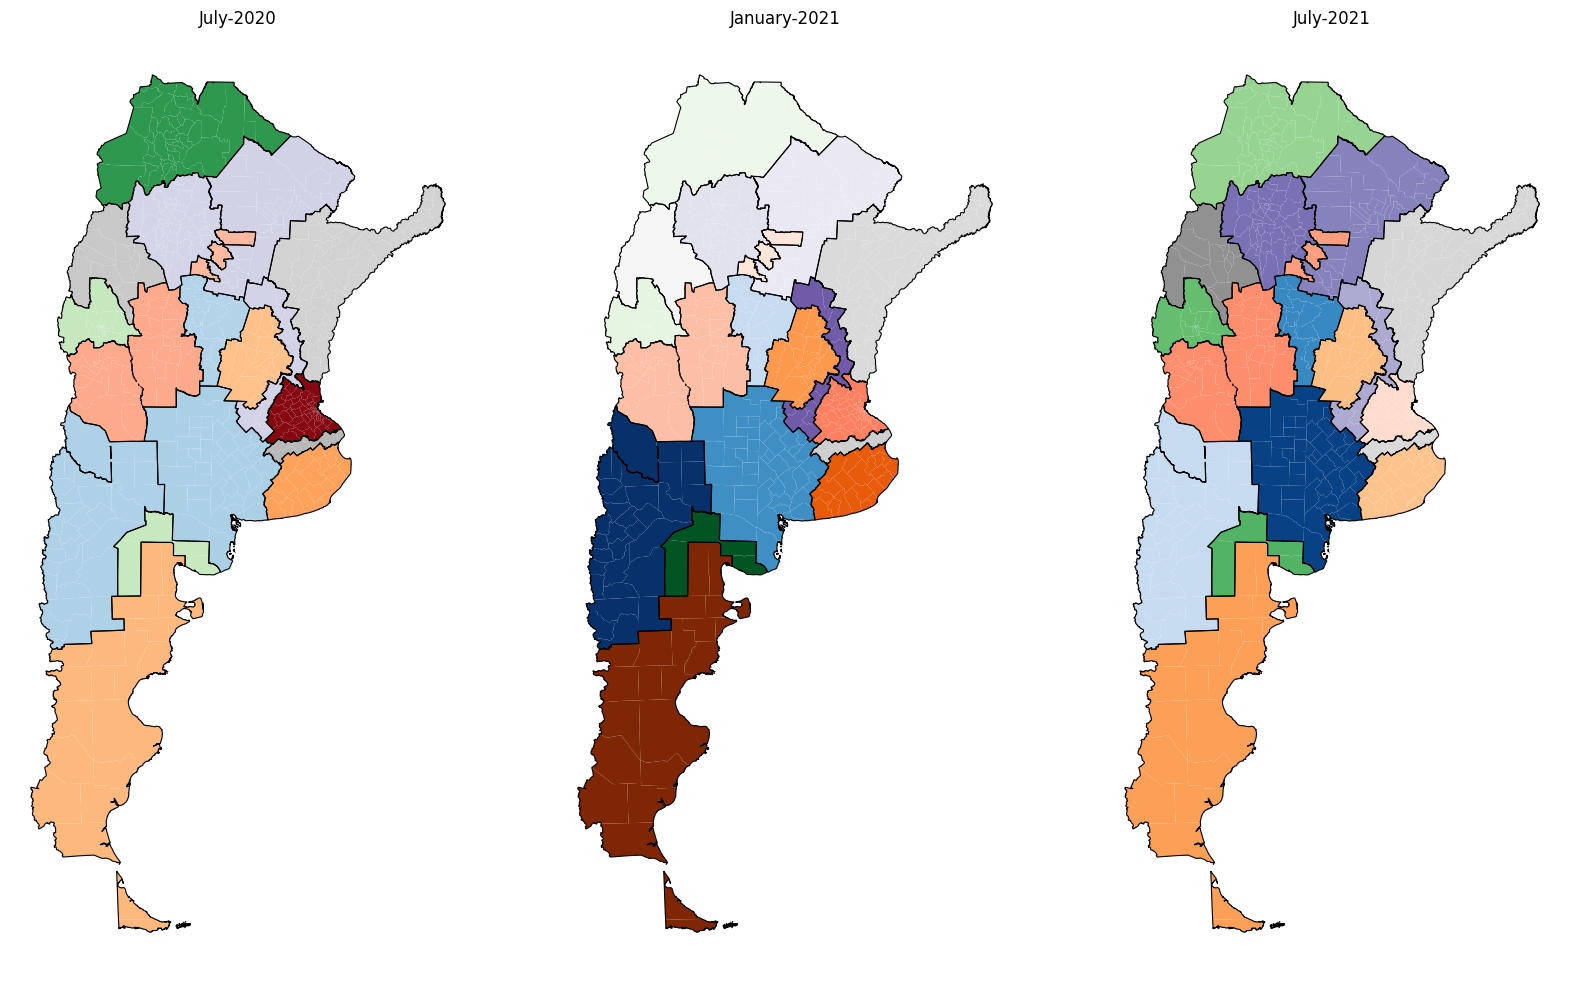

In [28]:
graficar_mapa_clusters(n_geo, sc.y_pred, geos,percentiles =(10,90)
                       , años=[index_months[4], index_months[10], index_months[16]], promedio=True)

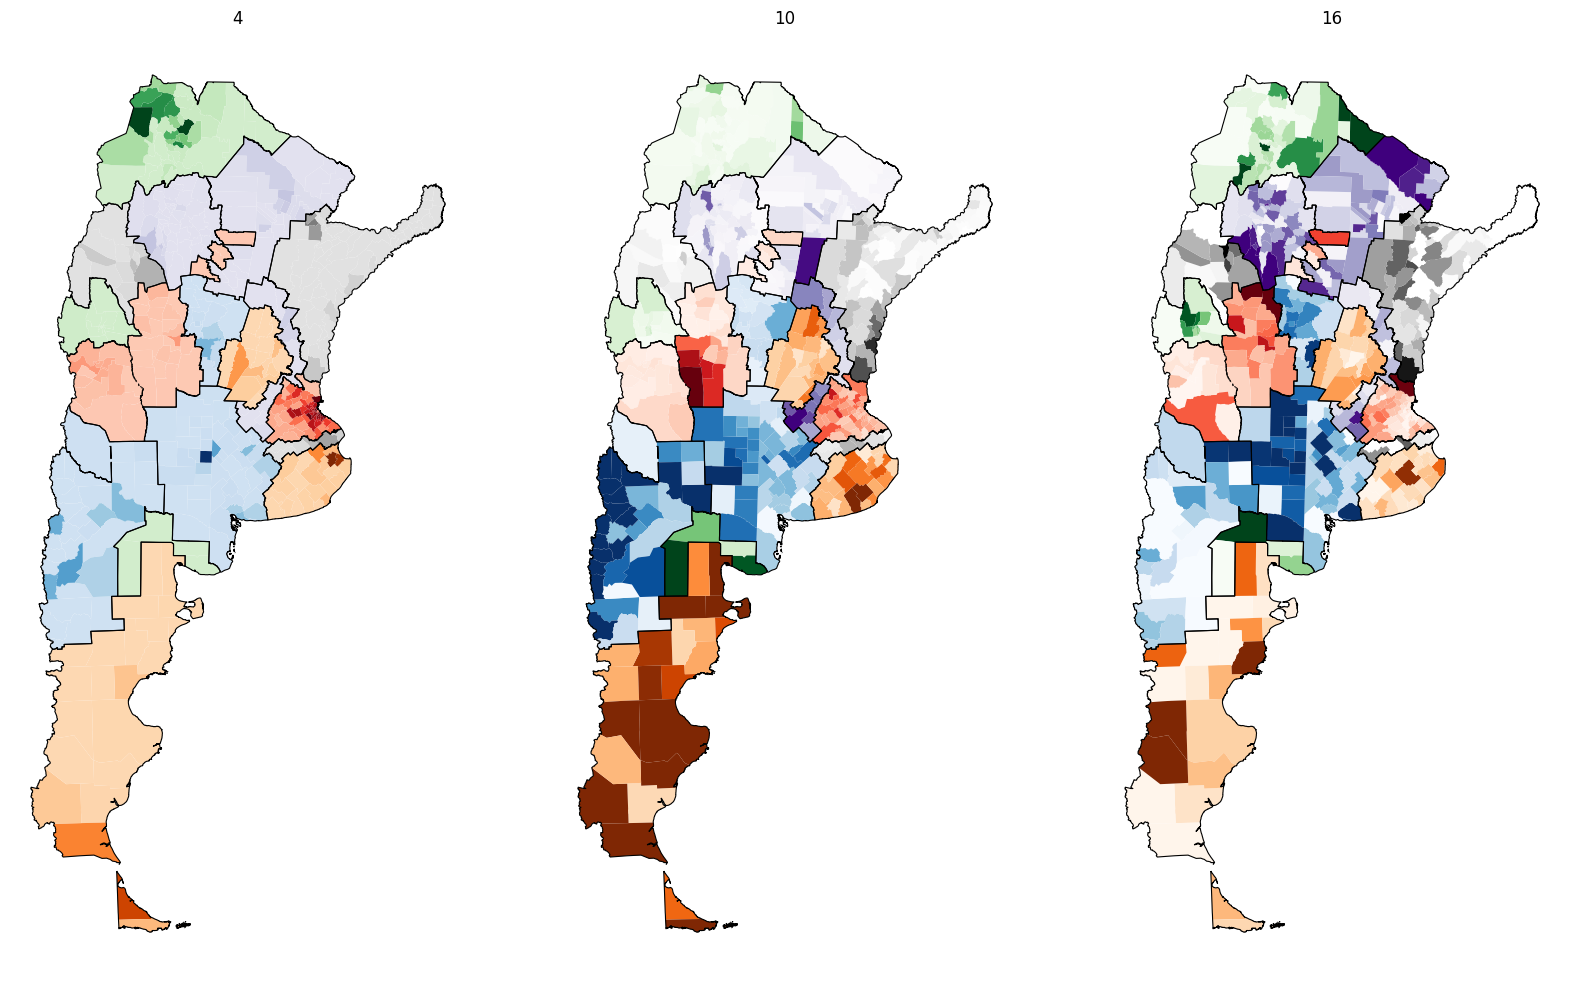

In [29]:
graficar_mapa_clusters(geo_prop, sc.y_pred, geos, años=['4', '10', '16'], promedio=False)